### 데이터 표준화를 위해 ID, TARGET 을 제외한 피처만 추출

In [4]:
X_features = cust_df.drop(['ID', 'TARGET'], axis=1)
y_labels = cust_df['TARGET']
cust_df['var3'] = cust_df['var3'].replace(-999999,2)

In [4]:
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist() # 제외
# duplicated_rows = X_features.duplicated()[X_features.duplicated()].index.tolist()

In [5]:
# 값이 동일한 중복 컬럼 개수
len(duplicated_cols)

62

### 분산 0 인 컬럼 확인 및 제거
- 변수들 간의 상관관계를 따질 때 도움이 안됨

In [8]:
# 1. 각 컬럼의 분산 계산
stds = X_features.std()

# 2. 분산이 0인(즉, 표준편차가 0이거나 값이 모두 똑같은) 컬럼 이름 추출
zero_var_cols = stds[stds == 0].index.tolist()

print(f"분산이 0인 컬럼 개수: {len(zero_var_cols)}")
print(f"삭제할 컬럼들: {zero_var_cols}")
# 분산이 0인 컬럼 개수: 34

# 3. 해당 컬럼들 제거
X_features_clean = X_features.drop(columns=zero_var_cols)

print(f"정제 전 피처 shape: {X_features.shape}")
print(f"정제 후 피처 shape: {X_features_clean.shape}")

분산이 0인 컬럼 개수: 34
삭제할 컬럼들: ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var41', 'ind_var46_0', 'ind_var46', 'num_var27_0', 'num_var28_0', 'num_var28', 'num_var27', 'num_var41', 'num_var46_0', 'num_var46', 'saldo_var28', 'saldo_var27', 'saldo_var41', 'saldo_var46', 'imp_amort_var18_hace3', 'imp_amort_var34_hace3', 'imp_reemb_var13_hace3', 'imp_reemb_var33_hace3', 'imp_trasp_var17_out_hace3', 'imp_trasp_var33_out_hace3', 'num_var2_0_ult1', 'num_var2_ult1', 'num_reemb_var13_hace3', 'num_reemb_var33_hace3', 'num_trasp_var17_out_hace3', 'num_trasp_var33_out_hace3', 'saldo_var2_ult1', 'saldo_medio_var13_medio_hace3']
정제 전 피처 shape: (76020, 369)
정제 후 피처 shape: (76020, 335)


In [47]:
duplicated_cols = X_features.T.duplicated()[X_features.T.duplicated()].index.tolist()
X_features.drop(columns=duplicated_cols, inplace=True)

# 희소 특징 제거 (99% 이상이 0으로 채워진 값)
# shape[0]으로 정확한 전체 행 수를 분모로 지정합니다.
num_rows = X_features.shape[0]
sparse_cols = [col for col in X_features.columns if (X_features[col] == 0).sum() / num_rows >= 0.99]
X_features.drop(columns=sparse_cols, inplace=True)
print(f"3. 희소 피처(99%가 0) 제거 후 피처 수: {X_features.shape[1]} (제거: {len(sparse_cols)}개)")
print("-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료\n")

3. 희소 피처(99%가 0) 제거 후 피처 수: 143 (제거: 164개)
-> 논문 플로우를 거쳐 최종 정제된 피처 개수 확보 완료



In [9]:
X_features['var38'] = np.log1p(X_features['var38'])

### DataFrame 형태 그대로 표준화

In [10]:
# StarndardScaler : 평균이 0, 분산 1로 데이터 분포로 변환(정규분포 변환 아님) => 중앙(0,0)으로 이동
# LogisticRegression 은 StarndardScaler 를 해야 성능이 나옴

# StandardScaler()로 평균이 0, 분산이 1 인 분포도 변환
scaler = StandardScaler()
X_features_scaled = pd.DataFrame(
    scaler.fit_transform(X_features),
    columns=X_features.columns
)
X_features_scaled

,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,...,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38
0,0.039074,-0.788249,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-1.615598
1,0.039074,0.060753,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-1.207690
2,0.039074,-0.788249,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-0.650805
3,0.039074,0.292298,-0.053388,0.361427,0.138158,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-0.741164
4,0.039074,0.446662,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,0.339528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76015,0.039074,1.141300,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-0.829178
76016,0.039074,0.446662,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,0.359541
76017,0.039074,-0.788249,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-0.481726
76018,0.039074,-0.633885,-0.053388,-0.213263,-0.218813,-0.038206,-0.042103,-0.013493,-0.015538,-0.033177,...,-0.005854,-0.017408,-0.011979,-0.015597,-0.016314,-0.01565,-0.012576,-0.018817,-0.019847,-0.250402


The no. of customers that are unsatisfied are 3008.
The no. of customers that are satisfied are 73012.



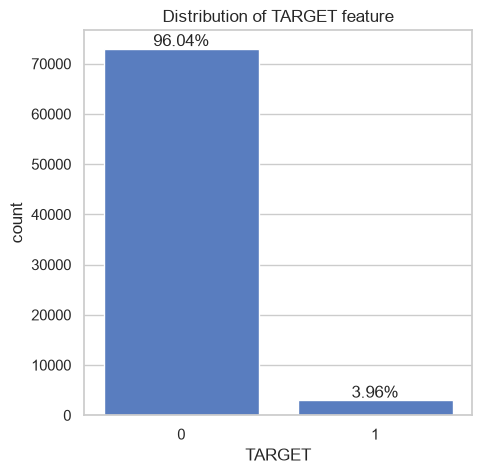

In [ ]:
def countplot_target(df,h=500,size=(5,5)):
    """
    It shows the frequency distribution of target variable 
    for a particular df for specific feature
    with percentage annoatations above. 
    It also prints the number of satisfactory and unsatisfactory customers.
    h : represents the additional height of the text above the bar
    size : figure size
    """
    plt.figure(figsize=size)
    ax = sns.countplot(x='TARGET',data=df)
    total = df.shape[0]
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x()+p.get_width()/2.,
                height + h,
                '{:1.2f}%'.format(height*100/total),
                ha="center") 
    plt.title("Distribution of TARGET feature")
    target_1 = df[df['TARGET']==1].shape[0]
    target_0 = df[df['TARGET']==0].shape[0]
    print("The no. of customers that are unsatisfied are %i."%(target_1))
    print("The no. of customers that are satisfied are %i."%(target_0))
    print('')
    plt.show()

In [29]:
def histplot_comb(col,train=cust_df,size=(20,5),bins=20):
    """
    Creates a histplots of train and 
    test data for feature var
    """
    var=col
    # plt.subplots(1,2,figsize=size)
    #plotting train data
    # plt.subplot(121)
    plt.title("Distribution of {} train data".format(var))
    plt.ylabel('No. of Occurences')
    plt.xlabel(var)
    plt.hist(train[var],bins=bins)
    plt.show()
    print("")

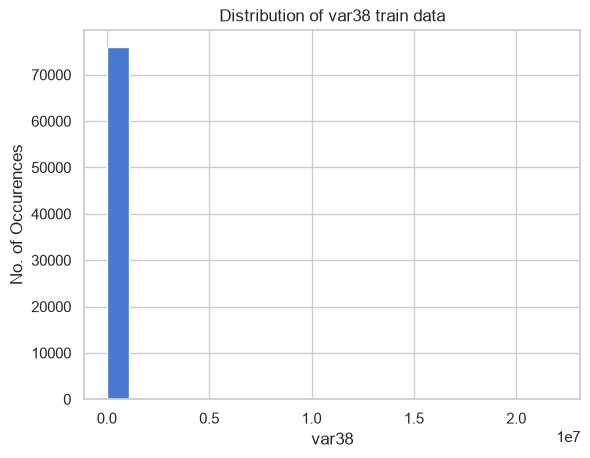

In [56]:
histplot_comb('var38')

### 학습/평가용 데이터로 분리

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42
)

# lbfgs는 반복적으로 손실을 줄여가는 최적화 알고리즘인데, 수렴 조건(그래디언트가 충분히 작아짐)을 만족하기 전에 max_iter 한도에 먼저 도달하면 "덜 수렴된 상태"에서 강제로 멈추고 이 ConvergenceWarning을 띄웁니다.
# 에러가 아니라 경고라 predict/predict_proba는 정상 동작하지만, 계수(coef_)가 진짜 최적값이 아니라 조금 덜 최적화된 상태일 수 있습니다(성능이 미세하게 낮게 나올 수 있음).
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# 학습 / 테스트 점수
# 신용카드 사기검출 모델 점수 :accuracy: 0.977, roc_auc:0.995
# 분산 0 컬럼 제거 전 : accuracy: 0.958, roc_auc: 0.810
# 분산 0 컬럼 제거 후 : accuracy: 0.959, roc_auc: 0.786
print('accuracy: {0:.3f}, roc_auc: {1:.3f}'.format(
    accuracy_score(y_test, lr_preds),
    roc_auc_score(y_test, lr_preds_proba)
))

accuracy: 0.958, roc_auc: 0.596


In [ ]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
# 여러개의 solver값 별로 LogisticRegression 학습 후 성능 평가
for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)
    lr_preds_proba = lr_clf.predict_proba(X_test)[:, 1]


    # accuracy와 roc_auc 측정
    print('solver:{0}, accuracy: {1:.3f}, roc_auc:{2:.3f}'.format(solver,
                                                                  accuracy_score(y_test, lr_preds),
                                                                  roc_auc_score(y_test , lr_preds_proba)))

solver:lbfgs, accuracy: 0.958, roc_auc:0.808
solver:liblinear, accuracy: 0.958, roc_auc:0.806
solver:newton-cg, accuracy: 0.958, roc_auc:0.806


c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


solver:sag, accuracy: 0.958, roc_auc:0.807


In [ ]:
from sklearn.model_selection import GridSearchCV

# 베스트 파라메터 찾기
params={'solver':['liblinear', 'lbfgs'],
        # 'penalty':['l2', 'l1'],
        'C':[0.01, 0.1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3 )
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_,
                                                  grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 0.1, 'solver': 'liblinear'}, 최적 평균 정확도:0.979


### Hyperopt 기반 최적화 파이프라인 (데이터 재수집 → 전처리 → StandardScaler → PCA → L1/L2 → class_weight)

기존 셀들(위쪽의 GridSearchCV 셀 등)이 다른 실습(유방암 데이터셋)의 잔재를 참조하고 있어 관련이 없고,
노트북 셀을 순서 없이 재실행하면서 `X_features`를 inplace로 계속 덮어써 상태가 꼬여 AUC가 흔들리는
문제가 있었습니다. 이 섹션은 **원본 CSV부터 다시 읽어** 아래 순서로 독립적으로 재구성한 파이프라인입니다.

1. 데이터 재로드 (`train.csv`, var3 -999999 → 2 보정)
2. 전처리: 중복 컬럼 제거 → 분산 0 컬럼 제거 → 희소(≥99% 0) 컬럼 제거 → var38 log1p → var15 파생 피처
3. StandardScaler (파이프라인 고정 단계)
4. PCA 차원축소 (사용 여부·설명분산비를 탐색 대상에 포함)
5. LogisticRegression의 L1/L2 정규화(penalty) + C + class_weight을 Hyperopt(TPE)로 탐색
6. 5-fold StratifiedKFold CV의 roc_auc를 목적함수로 최적 조합을 찾고, 홀드아웃 테스트셋으로 최종 평가

동일한 코드는 스크립트로도 분리되어 있습니다: `로지스틱회귀_최적화_파이프라인.py`
(터미널에서 `python "로지스틱회귀_최적화_파이프라인.py" --max-evals 30` 으로 재실행 가능, 약 1시간 소요)


In [ ]:
import numpy as np
import pandas as pd
from hyperopt import STATUS_OK, Trials, fmin, hp, space_eval, tpe
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


In [ ]:
# 1. 데이터 재로드 (기존 노트북 상태와 무관하게 원본 CSV부터 새로 읽음)
opt_df = pd.read_csv('../data/santander-customer-satisfaction/train.csv', encoding='latin-1')
opt_df['var3'] = opt_df['var3'].replace(-999999, 2)
print(f"원본 shape: {opt_df.shape}")
print(opt_df['TARGET'].value_counts(normalize=True))


In [ ]:
# 2. 전처리 함수 정의 및 적용
def remove_duplicate_columns(X):
    dup_mask = X.T.duplicated()
    dup_cols = X.columns[dup_mask].tolist()
    return X.drop(columns=dup_cols), dup_cols


def remove_zero_variance_columns(X):
    stds = X.std()
    zero_var_cols = stds[stds == 0].index.tolist()
    return X.drop(columns=zero_var_cols), zero_var_cols


def remove_sparse_columns(X, threshold=0.99):
    num_rows = X.shape[0]
    sparse_cols = [c for c in X.columns if (X[c] == 0).sum() / num_rows >= threshold]
    return X.drop(columns=sparse_cols), sparse_cols


def engineer_features(X):
    X = X.copy()
    X['var38'] = np.log1p(X['var38'])
    X['var15_below_23'] = (X['var15'] < 23).astype(int)
    X['var15_bin'] = pd.cut(X['var15'], bins=5, labels=False).astype(int)
    return X


opt_y = opt_df['TARGET']
opt_X = opt_df.drop(columns=['ID', 'TARGET'])

opt_X, dup_removed = remove_duplicate_columns(opt_X)
opt_X, zero_var_removed = remove_zero_variance_columns(opt_X)
opt_X, sparse_removed = remove_sparse_columns(opt_X)
opt_X = engineer_features(opt_X)

print(f"중복 컬럼 제거: {len(dup_removed)}개")
print(f"분산 0 컬럼 제거: {len(zero_var_removed)}개")
print(f"희소(>=99% 0) 컬럼 제거: {len(sparse_removed)}개")
print(f"최종 피처 수: {opt_X.shape[1]}")


In [ ]:
# 3. Train/Test Split (stratify로 96:4 비율 유지)
opt_X_train, opt_X_test, opt_y_train, opt_y_test = train_test_split(
    opt_X, opt_y, test_size=0.2, random_state=RANDOM_STATE, stratify=opt_y
)
print(f"train: {opt_X_train.shape}, test: {opt_X_test.shape}")


In [ ]:
# 4~5. StandardScaler + PCA(탐색) + L1/L2 + class_weight(탐색)을 하나의 Pipeline으로 구성
def resolve_class_weight(params):
    mode = params['class_weight_mode']
    if mode == 'none':
        return None
    if mode == 'balanced':
        return 'balanced'
    return {0: 1.0, 1: params['class_weight_1']}


def build_pipeline(params):
    steps = [('scaler', StandardScaler())]
    if params['use_pca']:
        steps.append(('pca', PCA(n_components=params['pca_n_components'], random_state=RANDOM_STATE)))
    steps.append((
        'clf',
        LogisticRegression(
            penalty=params['penalty'],
            C=params['C'],
            class_weight=resolve_class_weight(params),
            solver='liblinear',  # l1/l2 둘 다 지원
            max_iter=3000,
            random_state=RANDOM_STATE,
        ),
    ))
    return Pipeline(steps)


In [ ]:
# 6. Hyperopt(TPE)로 5-fold CV roc_auc를 최대화하는 조합 탐색
# 주의: 아래 fmin 실행은 PCA를 포함한 30회 탐색 기준 약 1시간이 걸렸습니다(Windows에서
# cross_val_score(n_jobs=-1)가 trial마다 프로세스 풀을 새로 띄우는 오버헤드가 큼).
# 재실행하지 않고 바로 다음 셀의 결과를 확인하려면 이 셀은 건너뛰어도 됩니다.

def objective(params, X_train, y_train, cv):
    pipe = build_pipeline(params)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return {'loss': -scores.mean(), 'status': STATUS_OK}


space = {
    'penalty': hp.choice('penalty', ['l1', 'l2']),
    'C': hp.loguniform('C', np.log(1e-3), np.log(10)),
    'class_weight_mode': hp.choice('class_weight_mode', ['none', 'balanced', 'custom']),
    'class_weight_1': hp.uniform('class_weight_1', 1.0, 30.0),
    'use_pca': hp.choice('use_pca', [False, True]),
    'pca_n_components': hp.uniform('pca_n_components', 0.80, 0.99),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trials = Trials()

best = fmin(
    fn=lambda params: objective(params, opt_X_train, opt_y_train, cv),
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(RANDOM_STATE),
)
best_params = space_eval(space, best)
best_cv_auc = -min(trials.losses())
print(f"최적 CV roc_auc: {best_cv_auc:.4f}")
print("최적 파라미터:")
for k, v in best_params.items():
    print(f"  - {k}: {v}")


In [ ]:
# 7. 최적 파라미터로 최종 모델 학습 및 홀드아웃 평가
final_pipe = build_pipeline(best_params)
final_pipe.fit(opt_X_train, opt_y_train)

opt_y_pred = final_pipe.predict(opt_X_test)
opt_y_proba = final_pipe.predict_proba(opt_X_test)[:, 1]

print(f"accuracy      : {accuracy_score(opt_y_test, opt_y_pred):.4f}")
print(f"roc_auc       : {roc_auc_score(opt_y_test, opt_y_proba):.4f}")
print(f"recall(class1): {recall_score(opt_y_test, opt_y_pred):.4f}")
print()
print(classification_report(opt_y_test, opt_y_pred, digits=4))


#### 실행 결과 (2026-08-20, `로지스틱회귀_최적화_파이프라인.py --max-evals 30` 실제 실행 결과)

- 전처리 후 피처 수: 369 → **145개** (중복 62 + 분산0 1 + 희소 163 제거)
- Hyperopt 5-fold CV 기준 최적 **roc_auc: 0.7996**
- 최적 파라미터: `penalty='l1'`, `C≈0.0094`, `class_weight='balanced'`, **`use_pca=False`**
  (PCA는 30회 탐색에서 채택되지 않음 — 이 데이터셋에서는 차원축소가 오히려 도움이 안 됨)

| 구분 | accuracy | roc_auc | recall(class 1) |
|---|---|---|---|
| Hyperopt 적용 후 | 0.7405 | **0.8102** | 0.7209 |

`class_weight='balanced'`로 클래스 불균형(96:4)을 보정한 결과, SMOTE를 썼을 때와 비슷한 패턴으로
accuracy는 낮아지지만(다수 클래스 몰빵 예측이 사라짐) roc_auc는 0.81 수준을 유지하면서 불만족 고객
(class 1) recall이 0.72까지 올라갑니다. SMOTE와 달리 합성 샘플을 만들지 않고 손실 함수의 클래스별
가중치만 조정하는 방식이라 데이터 누수 위험이 없고, 학습 데이터 크기도 그대로 유지됩니다.
